In [3]:
!pip install lightkurve

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 58.8 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=831cafb36adcbbb28c97cef6a685533841b65900c316c4441321d2ebaa31dd8e
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoization:

In [6]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 7 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: title={'center': 'Target ID: 246199087, Cadence: 4094110'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

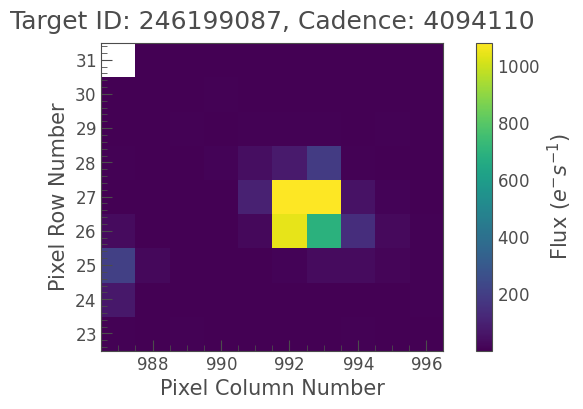

In [7]:
target = "TRAPPIST-1"

search = lk.search_targetpixelfile(target)
tpf = search.download()

tpf.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

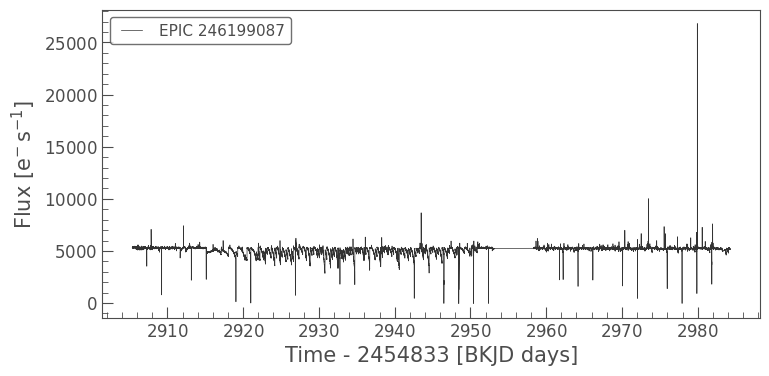

In [8]:
aperture_mask = tpf.pipeline_mask
lc = tpf.to_lightcurve(aperture_mask=aperture_mask)

lc = lc.remove_nans()
lc.plot()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

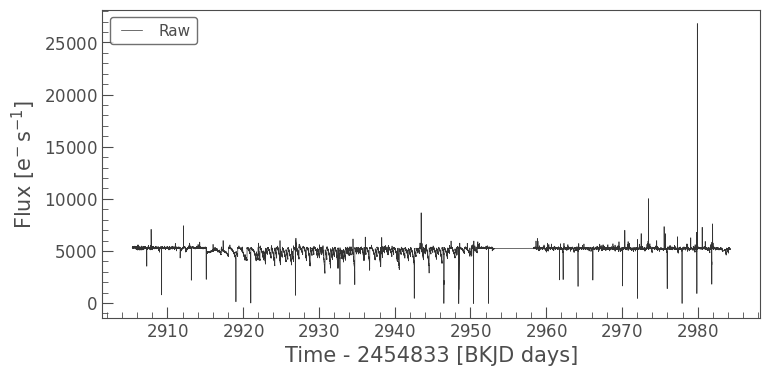

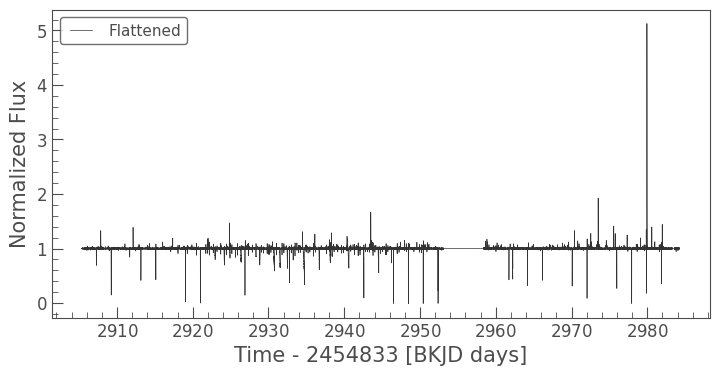

In [9]:
flat_lc = lc.flatten(window_length=201)

lc.plot(label="Raw")
flat_lc.plot(label="Flattened")

Detected Period: 1.9626462646264626 d


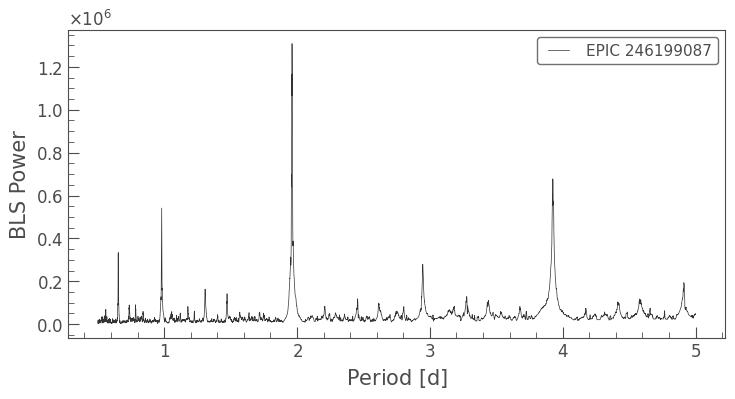

In [10]:
periods = np.linspace(0.5, 5, 10000)

bls = flat_lc.to_periodogram(method="bls", period=periods)

bls.plot()

best_period = bls.period_at_max_power
print("Detected Period:", best_period)

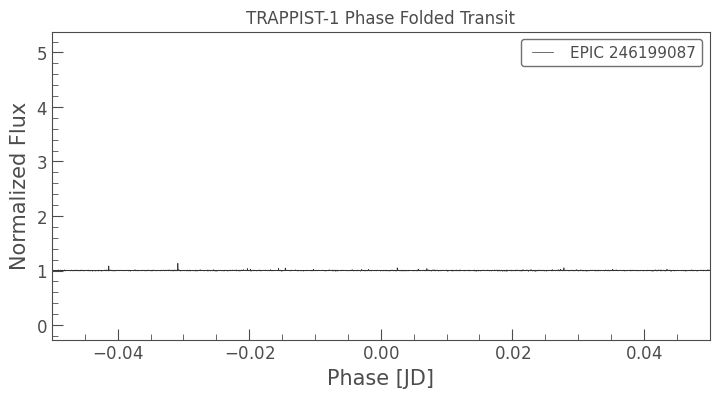

In [11]:
folded_lc = flat_lc.fold(period=best_period, epoch_time=best_period/2)

ax = folded_lc.plot()
ax.set_xlim(-0.05, 0.05)

plt.title("TRAPPIST-1 Phase Folded Transit")
plt.show()

In [12]:
flux = folded_lc.flux
flux = flux[~np.isnan(flux)]

sorted_flux = np.sort(flux)
transit_depth = 1 - np.median(sorted_flux[:100])

print("Transit Depth:", transit_depth)

Transit Depth: 0.904552334103379


In [13]:
rp_rs = np.sqrt(transit_depth)

print("Rp/Rs:", rp_rs)

Rp/Rs: 0.9510795624464753


In [14]:
time = folded_lc.time.value

threshold = np.median(flux) - 0.5 * transit_depth
in_transit = flux < threshold

duration = time[in_transit].max() - time[in_transit].min()

print("Transit Duration:", duration)

Transit Duration: 0.505485657318884


In [15]:
print("\n===== TRAPPIST-1 RESULTS =====")

print(f"Orbital Period: {best_period:.4f} days")
print(f"Transit Depth: {transit_depth:.6f}")
print(f"Rp/Rs: {rp_rs:.4f}")
print(f"Transit Duration: {duration:.4f} days")


===== TRAPPIST-1 RESULTS =====
Orbital Period: 1.9626 d days
Transit Depth: 0.904552
Rp/Rs: 0.9511
Transit Duration: 0.5055 days


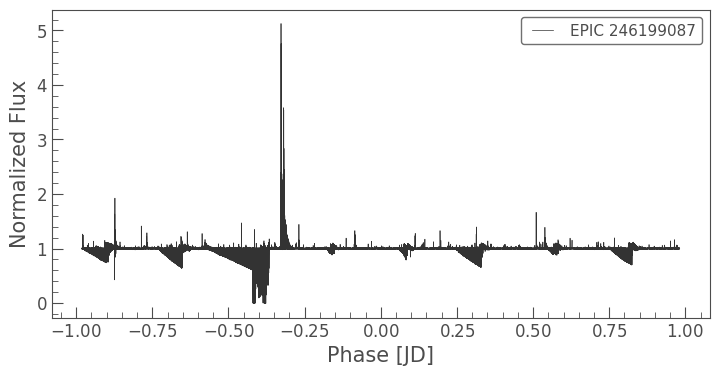

In [16]:
folded_lc.plot()
plt.savefig("trappist1_transit.png", dpi=300)